In [88]:
# Import core data manipulation libraries
import pandas as pd
import numpy as np

# Libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools from sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [89]:
# Load the German Credit dataset
# The dataset uses spaces as separators and does not contain column headers

df = pd.read_csv(
    "../data/german.data-numeric",
    sep=r"\s+",
    header=None
)

# Display first rows to inspect the dataset structure
df.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2


In [90]:
df.shape

(1000, 25)

reanaming columns for readability

In [91]:
# Assign column names based on the dataset documentation

df.columns = [
    "checking_account",
    "duration",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings",
    "employment",
    "installment_rate",
    "personal_status",
    "other_debtors",
    "residence_since",
    "property",
    "age",
    "installment_plans",
    "housing",
    "existing_credits",
    "job",
    "people_liable",
    "telephone",
    "foreign_worker",
    "extra1",
    "extra2",
    "extra3",
    "extra4",
    "risk"
]

# Verify the new column names
df.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status,other_debtors,...,existing_credits,job,people_liable,telephone,foreign_worker,extra1,extra2,extra3,extra4,risk
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2


In [92]:
df.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status,other_debtors,...,existing_credits,job,people_liable,telephone,foreign_worker,extra1,extra2,extra3,extra4,risk
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2


In [93]:
# Display dataset structure including number of rows, columns, and data types
df.info()

# Display statistical summary of numeric variables
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   checking_account   1000 non-null   int64
 1   duration           1000 non-null   int64
 2   credit_history     1000 non-null   int64
 3   purpose            1000 non-null   int64
 4   credit_amount      1000 non-null   int64
 5   savings            1000 non-null   int64
 6   employment         1000 non-null   int64
 7   installment_rate   1000 non-null   int64
 8   personal_status    1000 non-null   int64
 9   other_debtors      1000 non-null   int64
 10  residence_since    1000 non-null   int64
 11  property           1000 non-null   int64
 12  age                1000 non-null   int64
 13  installment_plans  1000 non-null   int64
 14  housing            1000 non-null   int64
 15  existing_credits   1000 non-null   int64
 16  job                1000 non-null   int64
 17  people_liable      1000 no

,checking_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status,other_debtors,...,existing_credits,job,people_liable,telephone,foreign_worker,extra1,extra2,extra3,extra4,risk
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000
mean,2.577000,20.903000,2.54500,32.711000,2.105000,3.384000,2.68200,2.845000,2.358000,35.546000,...,0.234000,0.103000,0.907000,0.041000,0.179000,0.713000,0.022000,0.2000,0.630000,1.300000
std,1.257638,12.058814,1.08312,28.252605,1.580023,1.208306,0.70808,1.103718,1.050209,11.375469,...,0.423584,0.304111,0.290578,0.198389,0.383544,0.452588,0.146757,0.4002,0.483046,0.458487
min,1.000000,4.000000,0.00000,2.000000,1.000000,1.000000,1.00000,1.000000,1.000000,19.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,1.000000
25%,1.000000,12.000000,2.00000,14.000000,1.000000,3.000000,2.00000,2.000000,1.000000,27.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,1.000000
50%,2.000000,18.000000,2.00000,23.000000,1.000000,3.000000,3.00000,3.000000,2.000000,33.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0000,1.000000,1.000000
75%,4.000000,24.000000,4.00000,40.000000,3.000000,5.000000,3.00000,4.000000,3.000000,42.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0000,1.000000,2.000000
max,4.000000,72.000000,4.00000,184.000000,5.000000,5.000000,4.00000,4.000000,4.000000,75.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000,2.000000


The dataset contains 1000 loan applications and 25 variables.
All variables are numeric because the dataset was converted to a numeric format suitable for machine learning algorithms.

Data Documentation gives: 1 = Good credit
2 = Bad credit; need to convert this to: 0 = Low Risk
1 = High Risk

In [94]:
# Convert the original risk variable
# Original dataset:
# 1 = Good credit
# 2 = Bad credit

# Assignment requirement:
# 0 = Low risk
# 1 = High risk

df["risk"] = np.where(df["risk"] == 2, 1, 0)

# Check distribution of risk categories
df["risk"].value_counts()

risk
0    700
1    300
Name: count, dtype: int64

results given: 700 Low Risk - 300 High Risk

Starting the Preprocessing part of the data

In [95]:
#checking missing values in the dataset
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

# check and remove duplicate rows if any exist
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

df = df.drop_duplicates()

# Check dataset shape after cleaning
df.shape

Missing values per column:
checking_account     0
duration             0
credit_history       0
purpose              0
credit_amount        0
savings              0
employment           0
installment_rate     0
personal_status      0
other_debtors        0
residence_since      0
property             0
age                  0
installment_plans    0
housing              0
existing_credits     0
job                  0
people_liable        0
telephone            0
foreign_worker       0
extra1               0
extra2               0
extra3               0
extra4               0
risk                 0
dtype: int64
Number of duplicate rows: 0


(1000, 25)

In [96]:
df.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status,other_debtors,...,existing_credits,job,people_liable,telephone,foreign_worker,extra1,extra2,extra3,extra4,risk
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,0
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,1
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,0
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,0
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,1


BONUS 1 — Correlation Heatmap. 
This heatmap helps identify relationships between variables and potential multicollinearity between features.

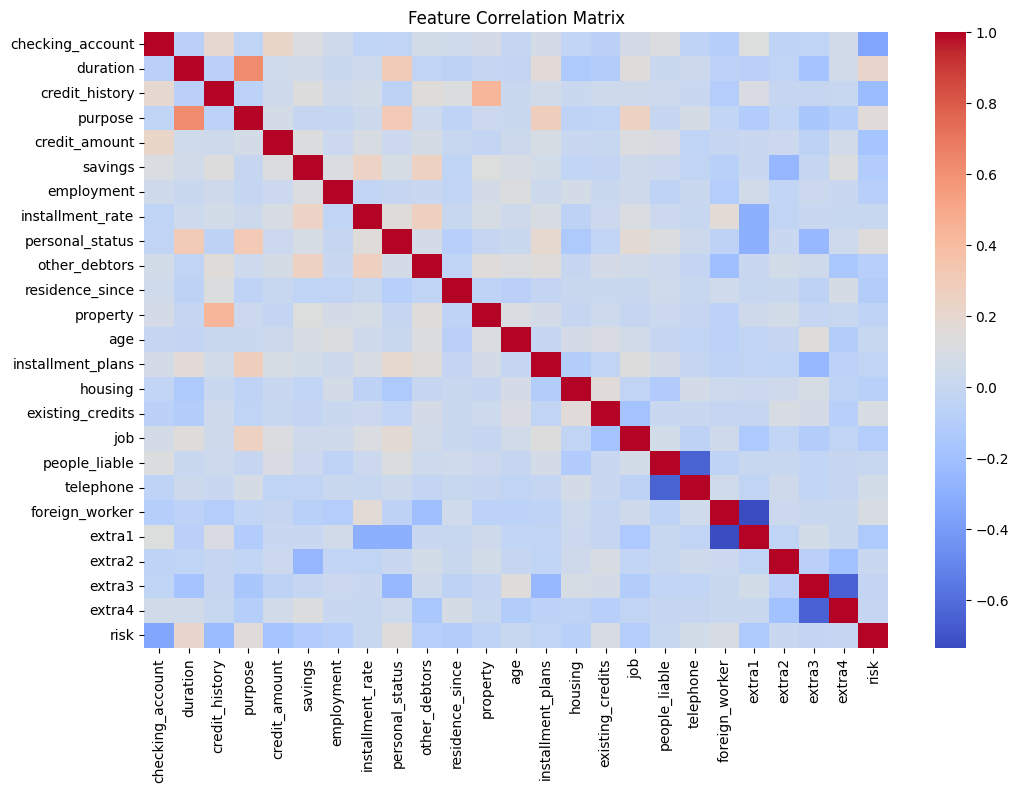

In [97]:
# Visualize correlation between features

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

Define Features and Labels

In [98]:
# Separate independent variables (features) and target variable
X = df.drop("risk", axis=1)
y = df["risk"]


Visualizing the distribution of the target variable

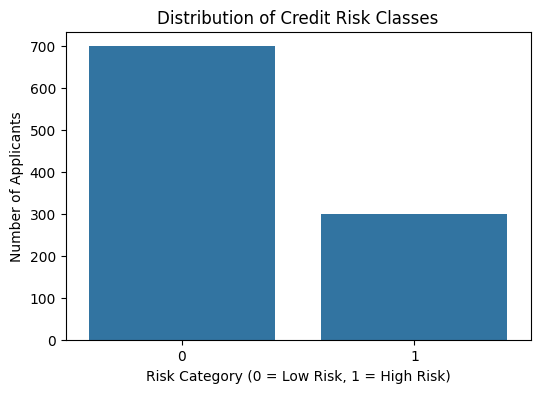

In [99]:
# This plot shows how many applicants fall into each risk category.
# It helps identify whether the dataset is balanced or imbalanced.

plt.figure(figsize=(6,4))
sns.countplot(x="risk", data=df)
plt.title("Distribution of Credit Risk Classes")
plt.xlabel("Risk Category (0 = Low Risk, 1 = High Risk)")
plt.ylabel("Number of Applicants")
plt.show()



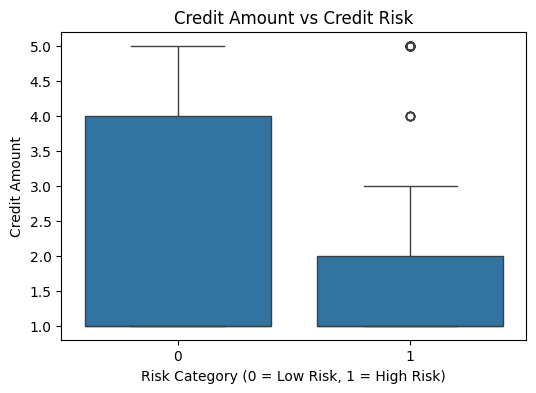

In [100]:
# Credit amount distribution by risk category - boxplot visualization

plt.figure(figsize=(6,4))
sns.boxplot(x="risk", y="credit_amount", data=df)
plt.title("Credit Amount vs Credit Risk")
plt.xlabel("Risk Category (0 = Low Risk, 1 = High Risk)")
plt.ylabel("Credit Amount")
plt.show()

Train/Test Split

800 rows → training
200 rows → testing

In [101]:
# Split dataset into training and testing sets
# 80% training data
# 20% testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Logistic Regression

In [102]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
log_model = LogisticRegression(max_iter=1000)
# Train the model
log_model.fit(X_train, y_train)
# Predict risk on test dataset
y_pred_log = log_model.predict(X_test)

# print predictions
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_log
})
comparison.head()

,Actual,Predicted
521,1,0
737,0,1
740,0,1
660,0,0
411,0,0


Random Forest

In [103]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest classifier
rf_model = RandomForestClassifier()
# Train the model
rf_model.fit(X_train, y_train)
# Predict risk using the trained model
y_pred_rf = rf_model.predict(X_test)

Cross Validation for Model Reliability - Cross-validation divides the dataset into multiple folds. The model is trained and tested multiple times on different subsets of the data to ensure consistent performance.

In [104]:
from sklearn.model_selection import cross_val_score

# Cross-validation evaluates the model across multiple
# training/testing splits to measure its stability.

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,  # 5-fold cross validation
    scoring="accuracy"
)

print("Cross Validation Scores:", cv_scores)

print("Average CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.77  0.74  0.775 0.76  0.775]
Average CV Accuracy: 0.764


Evaluate the Models

In [123]:
from sklearn.metrics import accuracy_score

# Calculate model accuracy

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_log))

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.78
Random Forest Accuracy: 0.77


ROC Curve for Random Forest Model - The ROC curve shows how well the model distinguishes between high-risk and low-risk applicants. AUC values closer to 1 indicate stronger model performance.

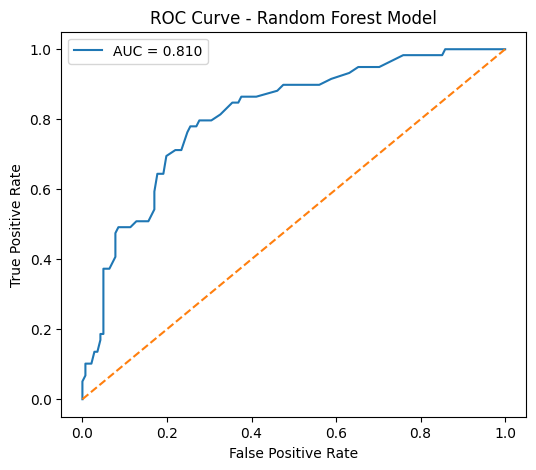

In [106]:
from sklearn.metrics import roc_curve, roc_auc_score

# The ROC curve measures the trade-off between
# true positive rate and false positive rate.

# Get probability predictions from the Random Forest model
y_probs = rf_model.predict_proba(X_test)[:,1]

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Calculate Area Under Curve (AUC)
auc_score = roc_auc_score(y_test, y_probs)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve - Random Forest Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Confusion Matrix

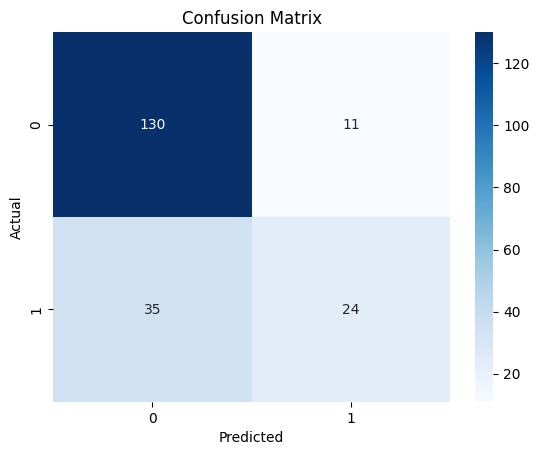

In [118]:
# Display confusion matrix for Random Forest model

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Model Comparison

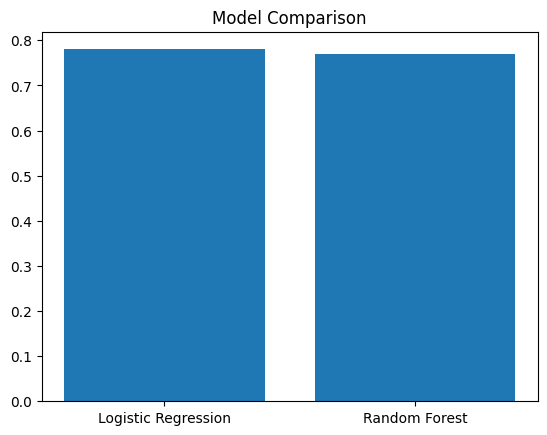

In [112]:
models = ["Logistic Regression", "Random Forest"]

scores = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.show()

Classification Report

In [117]:
# Generate classification report including precision, recall, and F1-score

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.79      0.92      0.85       141
           1       0.69      0.41      0.51        59

    accuracy                           0.77       200
   macro avg       0.74      0.66      0.68       200
weighted avg       0.76      0.77      0.75       200



In [121]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create a dataframe with evaluation metrics
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.78,0.674419,0.491525,0.568627
1,Random Forest,0.77,0.685714,0.406780,0.510638


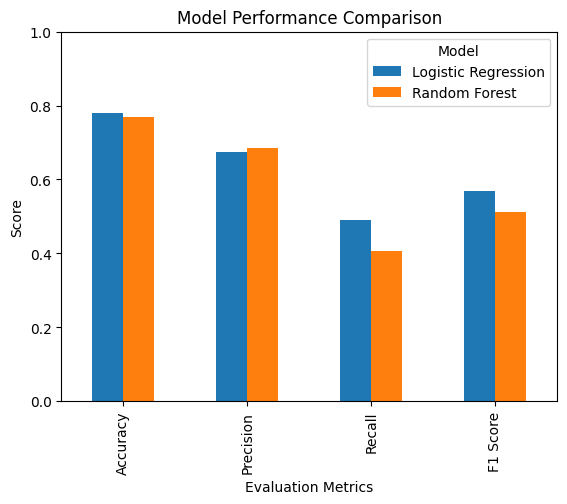

In [122]:
import matplotlib.pyplot as plt

# Transpose the dataframe so metrics become the x-axis
results_plot = results.set_index("Model").T

# Plot grouped bar chart
results_plot.plot(kind="bar")
plt.title("Model Performance Comparison")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend(title="Model")
plt.show()

Bonus 2: Feature Importance - 
Feature importance helps understand which financial variables contribute most to predicting credit risk.

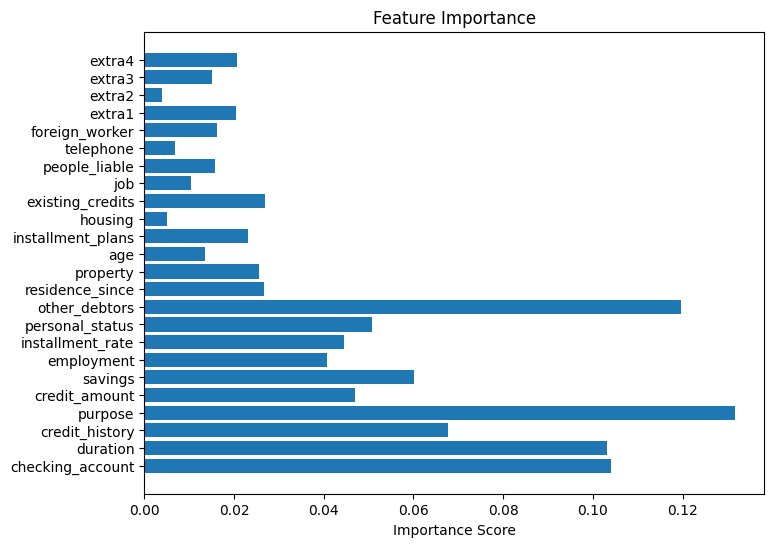

In [110]:
# Identify which features most influence credit risk predictions

importances = rf_model.feature_importances_

plt.figure(figsize=(8,6))

plt.barh(X.columns, importances)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.show()

BONUS 3: Model Accuracy Comparison Chart

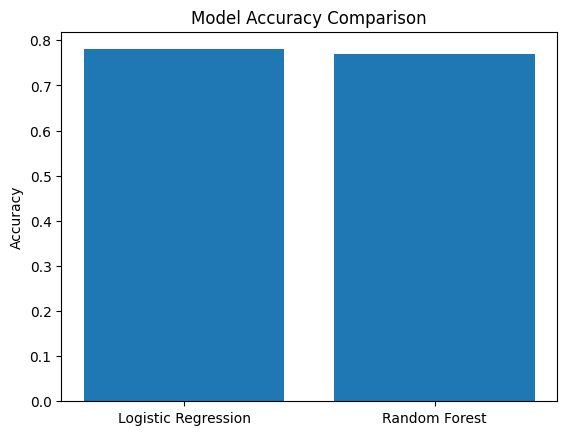

In [111]:
# Compare accuracy of both models visually

models = ["Logistic Regression", "Random Forest"]

scores = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, scores)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

Random Forest achieved higher accuracy compared to Logistic Regression.

This indicates that ensemble methods may better capture complex relationships between financial indicators and credit risk.

Such models can help financial institutions make better loan approval decisions and reduce the risk of default.